In [ ]:
# Cell 1 — Install libraries
!pip install -q tensorflow matplotlib seaborn scikit-learn Pillow

In [ ]:
# Cell 2 — Import everything
import os, zipfile, random, shutil
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from PIL import Image
from sklearn.metrics import classification_report, confusion_matrix

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.callbacks import (EarlyStopping,
    ReduceLROnPlateau, ModelCheckpoint)

print('TF:', tf.__version__)
print('GPU:', tf.config.list_physical_devices('GPU'))

TF: 2.19.0
GPU: []


In [ ]:
# Cell 3 — Upload zip file
from google.colab import files
print('Upload your casting zip file:')
uploaded = files.upload()

Upload your casting zip file:


Saving casting_512x512-20260405T082512Z-3-001.zip to casting_512x512-20260405T082512Z-3-001.zip


In [ ]:
# Cell 4 — Extract & verify folders
zip_name    = list(uploaded.keys())[0]
extract_dir = Path('/content/casting_raw')

with zipfile.ZipFile(zip_name, 'r') as z:
    z.extractall(extract_dir)
print('Extracted to:', extract_dir)

ok_dir  = next(extract_dir.rglob('ok_front'),  None)
def_dir = next(extract_dir.rglob('def_front'), None)
print('OK  dir:', ok_dir)
print('DEF dir:', def_dir)

ok_imgs  = [p for p in ok_dir.iterdir()
            if p.suffix.lower() in ('.jpeg','.jpg','.png')]
def_imgs = [p for p in def_dir.iterdir()
            if p.suffix.lower() in ('.jpeg','.jpg','.png')]
print(f'OK images : {len(ok_imgs)}')
print(f'DEF images: {len(def_imgs)}')

Extracted to: /content/casting_raw
OK  dir: /content/casting_raw/casting_512x512/ok_front
DEF dir: /content/casting_raw/casting_512x512/def_front
OK images : 519
DEF images: 781


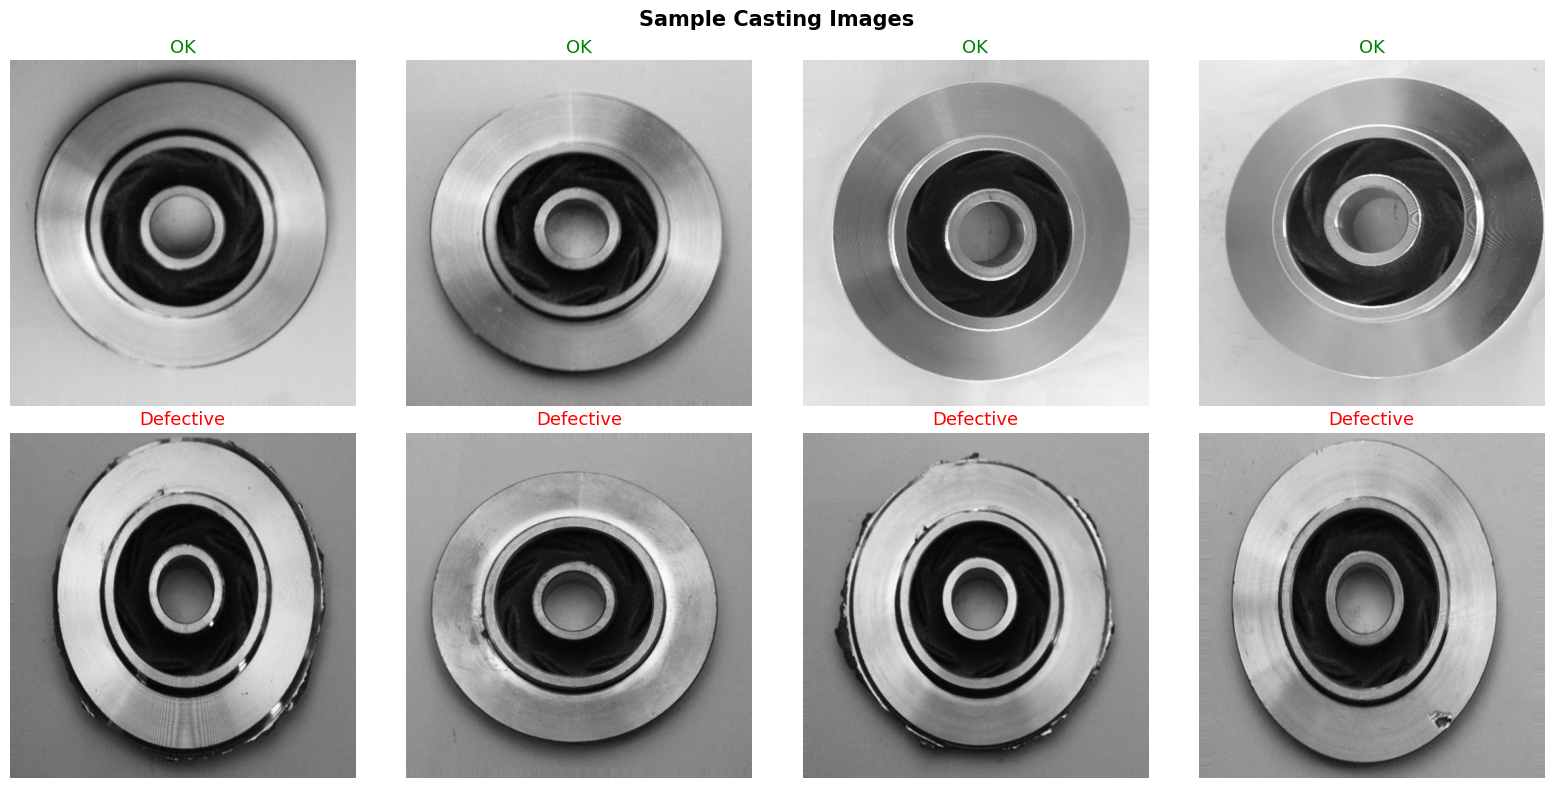

In [ ]:
# Cell 5 — Show sample images
def show_samples(n=4):
    ok_sample  = random.sample(ok_imgs,  n)
    def_sample = random.sample(def_imgs, n)
    fig, axes  = plt.subplots(2, n, figsize=(4*n, 8))
    for i, (ok, df) in enumerate(zip(ok_sample, def_sample)):
        axes[0,i].imshow(Image.open(ok))
        axes[0,i].set_title('OK',        color='green', fontsize=13)
        axes[0,i].axis('off')
        axes[1,i].imshow(Image.open(df))
        axes[1,i].set_title('Defective', color='red',   fontsize=13)
        axes[1,i].axis('off')
    plt.suptitle('Sample Casting Images', fontsize=15, fontweight='bold')
    plt.tight_layout(); plt.show()

show_samples()

In [ ]:
# Cell 6 — Split into train / val / test folders (70 / 15 / 15)
DATA_DIR = Path('/content/dataset')
SEED     = 42

def split_copy(images, class_name, train=0.70, val=0.15):
    random.seed(SEED)
    imgs = images.copy()
    random.shuffle(imgs)
    n    = len(imgs)
    n_tr = int(n * train)
    n_vl = int(n * val)
    splits = {
        'train': imgs[:n_tr],
        'val'  : imgs[n_tr:n_tr+n_vl],
        'test' : imgs[n_tr+n_vl:]
    }
    for split, paths in splits.items():
        dest = DATA_DIR / split / class_name
        dest.mkdir(parents=True, exist_ok=True)
        for p in paths:
            shutil.copy(p, dest / p.name)
    return {k: len(v) for k, v in splits.items()}

print('OK  split:', split_copy(ok_imgs,  'ok'))
print('DEF split:', split_copy(def_imgs, 'defective'))

OK  split: {'train': 363, 'val': 77, 'test': 79}
DEF split: {'train': 546, 'val': 117, 'test': 118}


In [ ]:
# Cell 7 — Create tf.data pipelines with augmentation
IMG_SIZE   = (224, 224)
BATCH_SIZE = 32
AUTOTUNE   = tf.data.AUTOTUNE

augment_layer = keras.Sequential([
    layers.RandomFlip('horizontal_and_vertical'),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
    layers.RandomBrightness(0.1),
    layers.RandomContrast(0.1),
])

def make_ds(split, augment=False):
    ds = tf.keras.utils.image_dataset_from_directory(
        DATA_DIR / split,
        image_size=IMG_SIZE,
        batch_size=BATCH_SIZE,
        label_mode='binary',
        seed=SEED,
        shuffle=(split == 'train')
    )
    if augment:
        ds = ds.map(
            lambda x, y: (augment_layer(x, training=True), y),
            num_parallel_calls=AUTOTUNE
        )
    return ds.prefetch(AUTOTUNE)

# ── Save class_names BEFORE prefetch wraps the dataset ──
_raw_train  = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR / 'train', image_size=IMG_SIZE,
    batch_size=BATCH_SIZE, label_mode='binary', seed=SEED
)
CLASS_NAMES = _raw_train.class_names   # save it here

train_ds = make_ds('train', augment=True)
val_ds   = make_ds('val')
test_ds  = make_ds('test')

print('Classes:', CLASS_NAMES)
print(f'Train={len(train_ds)} Val={len(val_ds)} Test={len(test_ds)} batches')

Found 909 files belonging to 2 classes.
Found 909 files belonging to 2 classes.
Found 194 files belonging to 2 classes.
Found 197 files belonging to 2 classes.
Classes: ['defective', 'ok']
Train=29 Val=7 Test=7 batches


In [ ]:
# Cell 8 — Build EfficientNetB0 transfer learning model
def build_model():
    backbone = EfficientNetB0(
        include_top=False,
        weights='imagenet',
        input_shape=(*IMG_SIZE, 3)
    )
    backbone.trainable = False

    inputs  = keras.Input(shape=(*IMG_SIZE, 3))
    x = backbone(inputs, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.3)(x)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(0.2)(x)
    outputs = layers.Dense(1, activation='sigmoid')(x)
    return keras.Model(inputs, outputs), backbone

model, backbone = build_model()
model.compile(
    optimizer=keras.optimizers.Adam(1e-3),
    loss='binary_crossentropy',
    metrics=['accuracy', keras.metrics.AUC(name='auc')]
)
model.summary()

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,218,788 (16.09 MB)

 Trainable params: 166,657 (651.00 KB)

 Non-trainable params: 4,052,131 (15.46 MB)

In [ ]:
# Cell 9 — Phase 1: train head with frozen backbone
cb1 = [
    EarlyStopping(patience=4, restore_best_weights=True,
                  monitor='val_auc', mode='max'),
    ReduceLROnPlateau(factor=0.5, patience=2,
                      monitor='val_loss', verbose=1),
    ModelCheckpoint('best_phase1.keras', save_best_only=True,
                    monitor='val_auc', mode='max')
]

history1 = model.fit(
    train_ds, validation_data=val_ds,
    epochs=10, callbacks=cb1
)
print('Phase 1 done.')

Epoch 1/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 107s 3s/step - accuracy: 0.8020 - auc: 0.8787 - loss: 0.4597 - val_accuracy: 0.8763 - val_auc: 0.9600 - val_loss: 0.3543 - learning_rate: 0.0010
Epoch 2/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 89s 3s/step - accuracy: 0.8933 - auc: 0.9641 - loss: 0.2425 - val_accuracy: 0.9124 - val_auc: 0.9784 - val_loss: 0.2800 - learning_rate: 0.0010
Epoch 3/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 86s 3s/step - accuracy: 0.9230 - auc: 0.9728 - loss: 0.2023 - val_accuracy: 0.9021 - val_auc: 0.9903 - val_loss: 0.2840 - learning_rate: 0.0010
Epoch 4/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 139s 3s/step - accuracy: 0.9208 - auc: 0.9766 - loss: 0.1948 - val_accuracy: 0.9485 - val_auc: 0.9913 - val_loss: 0.2105 - learning_rate: 0.0010
Epoch 5/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 141s 3s/step - accuracy: 0.9417 - auc: 0.9858 - loss: 0.1475 - val_accuracy: 0.9588 - val_auc: 0.9970 - val_loss: 0.1633 - learning_rate: 0.0010
Epoch 6/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 82s 3s/step - accuracy: 0.9483 - auc: 0.9862 - lo

In [ ]:
# Cell 10 — Phase 2: fine-tune top 30 backbone layers
backbone.trainable = True
for layer in backbone.layers[:-30]:
    layer.trainable = False

model.compile(
    optimizer=keras.optimizers.Adam(1e-5),
    loss='binary_crossentropy',
    metrics=['accuracy', keras.metrics.AUC(name='auc')]
)

cb2 = [
    EarlyStopping(patience=5, restore_best_weights=True,
                  monitor='val_auc', mode='max'),
    ReduceLROnPlateau(factor=0.5, patience=3,
                      monitor='val_loss', verbose=1),
    ModelCheckpoint('best_phase2.keras', save_best_only=True,
                    monitor='val_auc', mode='max')
]

history2 = model.fit(
    train_ds, validation_data=val_ds,
    epochs=20, callbacks=cb2
)
print('Phase 2 done.')

Epoch 1/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 116s 3s/step - accuracy: 0.7998 - auc: 0.8734 - loss: 0.4819 - val_accuracy: 0.9639 - val_auc: 0.9998 - val_loss: 0.1236 - learning_rate: 1.0000e-05
Epoch 2/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 103s 4s/step - accuracy: 0.8273 - auc: 0.9002 - loss: 0.4209 - val_accuracy: 0.9588 - val_auc: 0.9996 - val_loss: 0.1243 - learning_rate: 1.0000e-05
Epoch 3/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 102s 3s/step - accuracy: 0.8427 - auc: 0.9201 - loss: 0.3662 - val_accuracy: 0.9639 - val_auc: 0.9991 - val_loss: 0.1150 - learning_rate: 1.0000e-05
Epoch 4/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 103s 4s/step - accuracy: 0.8405 - auc: 0.9167 - loss: 0.3782 - val_accuracy: 0.9639 - val_auc: 0.9983 - val_loss: 0.1090 - learning_rate: 1.0000e-05
Epoch 5/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 95s 3s/step - accuracy: 0.8735 - auc: 0.9393 - loss: 0.3184 - val_accuracy: 0.9639 - val_auc: 0.9962 - val_loss: 0.1126 - learning_rate: 1.0000e-05
Epoch 6/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 101s 3s/step - accuracy: 0.8

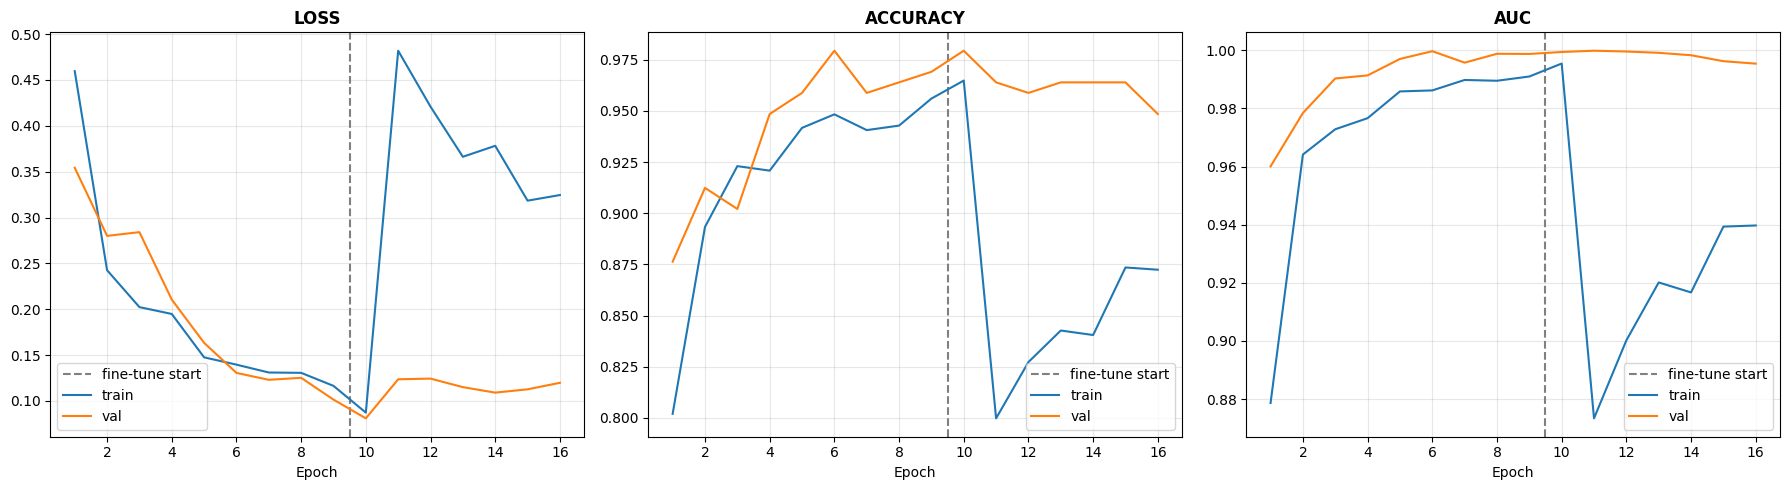

In [ ]:
# Cell 11 — Plot training curves
def plot_history(h1, h2=None):
    metrics = ['loss', 'accuracy', 'auc']
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    for ax, m in zip(axes, metrics):
        tr = h1.history[m]
        vl = h1.history[f'val_{m}']
        if h2:
            ep_sep = len(tr)
            tr += h2.history[m]
            vl += h2.history[f'val_{m}']
            ax.axvline(ep_sep - 0.5, color='gray',
                       linestyle='--', label='fine-tune start')
        ep = range(1, len(tr)+1)
        ax.plot(ep, tr, label='train')
        ax.plot(ep, vl, label='val')
        ax.set_title(m.upper(), fontweight='bold')
        ax.set_xlabel('Epoch'); ax.legend(); ax.grid(alpha=0.3)
    plt.tight_layout(); plt.show()

plot_history(history1, history2)

In [ ]:
# Cell 12 — Evaluate on test set
best = keras.models.load_model('best_phase2.keras')
loss, acc, auc = best.evaluate(test_ds, verbose=1)
print(f'\nTest Accuracy : {acc:.4f}')
print(f'Test AUC      : {auc:.4f}')

7/7 ━━━━━━━━━━━━━━━━━━━━ 18s 2s/step - accuracy: 0.9594 - auc: 0.9917 - loss: 0.1531

Test Accuracy : 0.9594
Test AUC      : 0.9917


              precision    recall  f1-score   support

   defective       0.99      0.94      0.97       118
          ok       0.92      0.99      0.95        79

    accuracy                           0.96       197
   macro avg       0.95      0.96      0.96       197
weighted avg       0.96      0.96      0.96       197



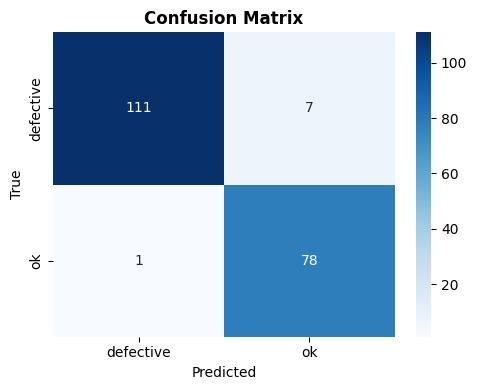

In [ ]:
# Cell 13 — Confusion matrix & classification report
y_true, y_prob = [], []
for imgs, labels in test_ds:
    preds = best.predict(imgs, verbose=0)
    y_prob.extend(preds.flatten())
    y_true.extend(labels.numpy().flatten())

y_pred = (np.array(y_prob) >= 0.5).astype(int)
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES))

cm = confusion_matrix(y_true, y_pred)
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES,
            yticklabels=CLASS_NAMES, ax=ax)
ax.set_ylabel('True'); ax.set_xlabel('Predicted')
ax.set_title('Confusion Matrix', fontweight='bold')
plt.tight_layout(); plt.show()

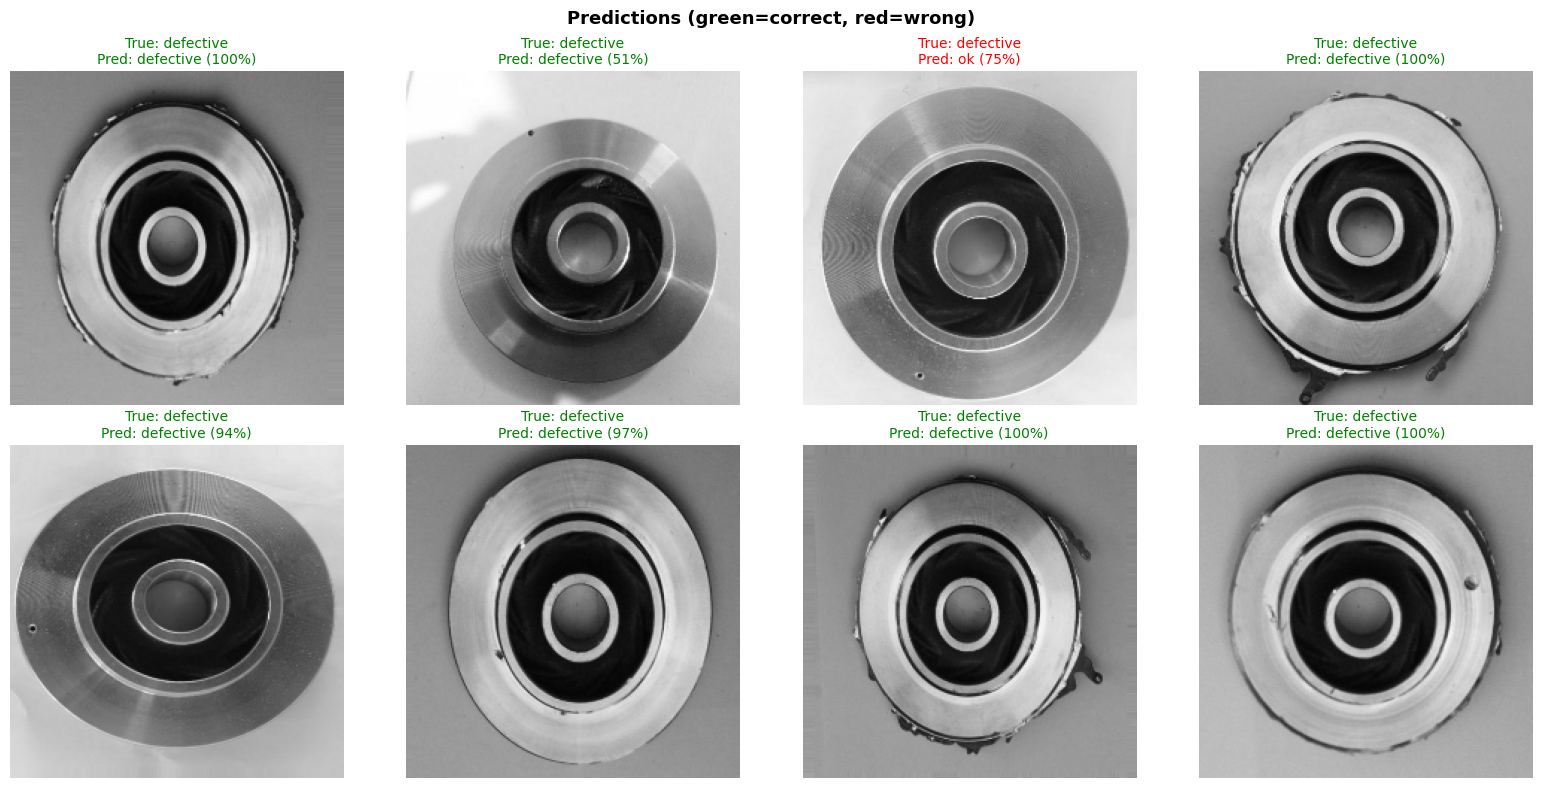

In [ ]:
# Cell 14 — Visualise predictions on test batch
imgs_batch, labels_batch = next(iter(test_ds))
preds = best.predict(imgs_batch[:8], verbose=0).flatten()

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for i, ax in enumerate(axes.flatten()):
    img   = imgs_batch[i].numpy().astype('uint8')
    true  = int(labels_batch[i])
    pred  = int(preds[i] >= 0.5)
    conf  = preds[i] if pred == 1 else 1 - preds[i]
    color = 'green' if true == pred else 'red'
    ax.imshow(img)
    ax.set_title(
        f'True: {CLASS_NAMES[true]}\nPred: {CLASS_NAMES[pred]} ({conf:.0%})',
        color=color, fontsize=10
    )
    ax.axis('off')
plt.suptitle('Predictions (green=correct, red=wrong)',
             fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

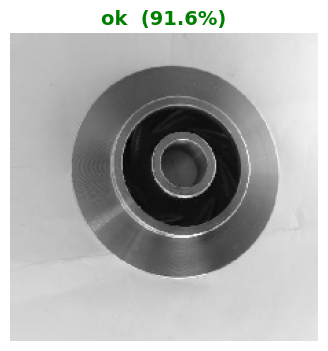

ok 0.916


In [ ]:
# Cell 15 — Single image prediction
def predict_image(path):
    img  = tf.keras.utils.load_img(path, target_size=IMG_SIZE)
    arr  = tf.expand_dims(tf.keras.utils.img_to_array(img), 0)
    prob = best.predict(arr, verbose=0)[0][0]
    pred = int(prob >= 0.5)
    conf = prob if pred == 1 else 1 - prob
    color = 'green' if CLASS_NAMES[pred] == 'ok' else 'red'
    plt.figure(figsize=(4, 4))
    plt.imshow(img)
    plt.title(f'{CLASS_NAMES[pred]}  ({conf:.1%})',
              color=color, fontsize=14, fontweight='bold')
    plt.axis('off'); plt.show()
    return CLASS_NAMES[pred], float(conf)

# Test on a random image from the test set
sample = random.choice(
    list((DATA_DIR / 'test' / 'ok').glob('*.jpeg')))
label, confidence = predict_image(sample)
print(label, round(confidence, 4))

In [ ]:
# Cell 16 — Save & download model
best.save('casting_defect_model.keras')
print('Model saved.')
files.download('casting_defect_model.keras')

Model saved.


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Upload a casting image (defect or ok):


Saving cast_ok_0_2288.jpeg to cast_ok_0_2288.jpeg


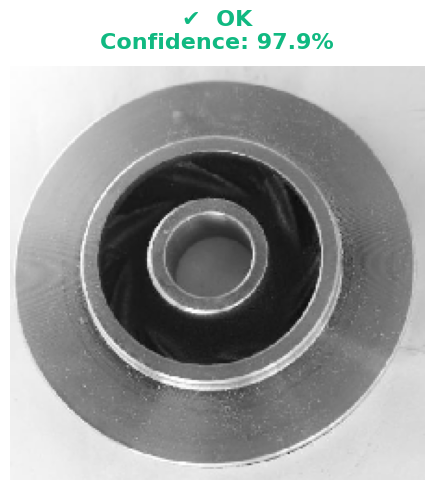

Label: ok  |  Confidence: 97.9%


In [ ]:
# Cell 17 — Upload and predict on a single image with styled output

import matplotlib.pyplot as plt
from PIL import Image
import tensorflow as tf
from google.colab import files

print("Upload a casting image (defect or ok):")
uploaded = files.upload()
img_path = list(uploaded.keys())[0]

# Load & preprocess
img = tf.keras.utils.load_img(img_path, target_size=IMG_SIZE)
arr = tf.expand_dims(tf.keras.utils.img_to_array(img), 0)

# Predict
prob = best.predict(arr, verbose=0)[0][0]
pred = int(prob >= 0.5)
conf = prob if pred == 1 else 1 - prob
label = CLASS_NAMES[pred]

# Styled plot
color  = "#10B981" if label == "ok" else "#EF4444"
symbol = "✔  OK"   if label == "ok" else "✘  DEFECTIVE"

fig, ax = plt.subplots(figsize=(5, 5))
ax.imshow(img)
ax.axis("off")
ax.set_title(f"{symbol}\nConfidence: {conf:.1%}",
             fontsize=16, fontweight="bold", color=color, pad=12)

for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_edgecolor(color)
    spine.set_linewidth(6)

plt.tight_layout()

out_path = "prediction_result.png"
plt.savefig(out_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Label: {label}  |  Confidence: {conf:.1%}")

In [ ]:
# Cell 18 — Download the prediction image

files.download("prediction_result.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>